# Analyze per Die Matrix

This notebook demonstrates how to find the **reference behavior** for each die matrix, compare individual pieces against it, and identify which process segments show the most variability.

All analysis is performed on the gold parquet dataset (clean, validated pieces with partial times).

In [3]:
# TODO: implement this cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/gold/pieces.parquet")

print(f"Rows: {len(df):,}")
print(f"Die matrices: {sorted(df['die_matrix'].unique())}")

Rows: 169,161
Die matrices: [np.int64(4974), np.int64(5052), np.int64(5090), np.int64(5091)]


## 1. Reference profile per die matrix

The **reference (optimal) behavior** for each die matrix is defined by its median cumulative times. The median is more robust than the mean — it is not pulled by residual edge cases.

This table shows how long a typical piece takes to reach each stage, per matrix.

In [4]:
# TODO: implement this cell

lifetime_cols = [
  "lifetime_2nd_strike_s", "lifetime_3rd_strike_s", "lifetime_4th_strike_s",
  "lifetime_auxiliary_press_s", "lifetime_bath_s"
]

reference = df.groupby("die_matrix")[lifetime_cols].median().round(2)

print("=== REFERENCE CUMULATIVE TIMES PER DIE MATRIX (median seconds) ===")
print()
print(reference.to_string())

=== REFERENCE CUMULATIVE TIMES PER DIE MATRIX (median seconds) ===

            lifetime_2nd_strike_s  lifetime_3rd_strike_s  lifetime_4th_strike_s  lifetime_auxiliary_press_s  lifetime_bath_s
die_matrix                                                                                                                  
4974                         17.3                   23.9                   37.1                        54.2             56.0
5052                         18.3                   25.3                   39.3                        56.7             58.3
5090                         17.7                   24.6                   38.5                        56.5             58.1
5091                         18.5                   25.6                   38.2                        57.5             59.1


## 2. Reference partial times per die matrix

The partial times (time spent **between** consecutive stages) are more diagnostically useful than cumulative times — they isolate each segment of the process.

In [5]:
# TODO: implement this cell

partial_cols = [
  "partial_furnace_to_2nd_strike_s",
  "partial_2nd_to_3rd_strike_s",
  "partial_3rd_to_4th_strike_s",
  "partial_4th_strike_to_auxiliary_press_s",
  "partial_auxiliary_press_to_bath_s"
]

reference_partials = df.groupby("die_matrix")[partial_cols].median().round(2)

print("=== REFERENCE PARTIAL TIMES PER DIE MATRIX (median seconds) ===")
print()
print(reference_partials.to_string())


=== REFERENCE PARTIAL TIMES PER DIE MATRIX (median seconds) ===

            partial_furnace_to_2nd_strike_s  partial_2nd_to_3rd_strike_s  partial_3rd_to_4th_strike_s  partial_4th_strike_to_auxiliary_press_s  partial_auxiliary_press_to_bath_s
die_matrix                                                                                                                                                                       
4974                                   17.3                          6.5                         13.1                                     17.0                                1.8
5052                                   18.3                          6.9                         13.7                                     17.3                                1.6
5090                                   17.7                          6.8                         13.8                                     17.7                                1.6
5091                                   18.5  

## 3. Variability per segment per die matrix

Which segments are most variable? High standard deviation relative to the median (coefficient of variation) indicates segments where the process is less stable — these are the primary candidates for delay investigation.

**CV = std / median × 100%** — higher CV means more variability relative to the typical value.

In [6]:
# TODO: implement this cell

cv = df.groupby("die_matrix")[partial_cols].apply(
  lambda g: (g.std() / g.median() * 100).round(1)
).reset_index()

print("=== COEFFICIENT OF VARIATION PER SEGMENT PER MATRIX (%) ===")
print("Higher CV = more variable = less stable process segment")
print()
print(cv.set_index("die_matrix").to_string())

=== COEFFICIENT OF VARIATION PER SEGMENT PER MATRIX (%) ===
Higher CV = more variable = less stable process segment

            partial_furnace_to_2nd_strike_s  partial_2nd_to_3rd_strike_s  partial_3rd_to_4th_strike_s  partial_4th_strike_to_auxiliary_press_s  partial_auxiliary_press_to_bath_s
die_matrix                                                                                                                                                                       
4974                                    9.1                          4.1                          2.4                                      5.2                                2.7
5052                                   10.4                          7.3                          6.2                                      6.6                                3.1
5090                                   13.6                         10.9                          8.1                                      9.1                             

## 4. Deviation from reference per piece

For each piece, compute the deviation from its die matrix reference at each stage. Positive deviation = slower than reference. This allows identifying both slow individual pieces and systematic drifts.

In [7]:
# TODO: implement this cell

# Merge reference partials onto each piece
df_dev = df.copy()
ref = reference_partials.reset_index()

for col in partial_cols:
  ref_map = ref.set_index("die_matrix")[col]
  df_dev[f"dev_{col}"] = df_dev[col] - df_dev["die_matrix"].map(ref_map)

dev_cols = [f"dev_{c}" for c in partial_cols]

print("=== DEVIATION FROM REFERENCE (sample — first 5 rows) ===")
print("Positive = slower than reference, Negative = faster")
print()
print(df_dev[["piece_id", "die_matrix"] + dev_cols].head().to_string())


=== DEVIATION FROM REFERENCE (sample — first 5 rows) ===
Positive = slower than reference, Negative = faster

       piece_id  die_matrix  dev_partial_furnace_to_2nd_strike_s  dev_partial_2nd_to_3rd_strike_s  dev_partial_3rd_to_4th_strike_s  dev_partial_4th_strike_to_auxiliary_press_s  dev_partial_auxiliary_press_to_bath_s
0  251106001721        5052                            -0.400000                        -0.199999                        -0.300000                                -7.000015e-01                               0.000002
1  251106001722        5052                            -0.400000                        -0.199999                        -0.399999                                -4.000023e-01                               0.000002
2  251106001723        5052                            -0.099999                        -0.300002                        -0.200000                                -3.000000e-01                               0.000002
3  251106001724        5052   

## 5. Identify slow pieces and their penalized segment

A piece is considered **slow** if its total bath time exceeds the 90th percentile for its die matrix. For each slow piece, identify which segment contributed the most delay.

In [11]:
# Compute 90th percentile bath time per matrix
p90 = df.groupby("die_matrix")["lifetime_bath_s"].quantile(0.90)

# Flag slow pieces
df_dev["is_slow"] = df_dev["lifetime_bath_s"] > df_dev["die_matrix"].map(p90)

# For each slow piece, find which partial had the highest positive deviation
df_slow = df_dev[df_dev["is_slow"]].copy()
df_slow["penalized_segment"] = (
  df_slow[dev_cols]
  .idxmax(axis=1)
  .str.replace("dev_partial_", "", regex=False)
  .str.removesuffix("_s")
)

print(f"=== SLOW PIECES (bath > 90th percentile per matrix) ===")
print()
print(f"90th percentile bath times:")
for matrix, val in p90.items():
  print(f"  Matrix {matrix}: {val:.1f}s")
print()
print(f"Total slow pieces: {len(df_slow):,} ({len(df_slow)/len(df)*100:.1f}% of all pieces)")

=== SLOW PIECES (bath > 90th percentile per matrix) ===

90th percentile bath times:
  Matrix 4974: 59.0s
  Matrix 5052: 61.8s
  Matrix 5090: 62.9s
  Matrix 5091: 63.4s

Total slow pieces: 16,549 (9.8% of all pieces)


## 6. Slow pieces per die matrix

How slow pieces distribute across die matrices, and which segments are most often penalized per matrix.

In [12]:
# TODO: implement this cell

print("=== SLOW PIECES PER DIE MATRIX ===")
print()

summary = df_slow.groupby("die_matrix").agg(
  slow_pieces=("piece_id", "count"),
  most_penalized_segment=("penalized_segment", lambda x: x.value_counts().index[0])
).reset_index()

summary["total_pieces"] = summary["die_matrix"].map(df.groupby("die_matrix").size())
summary["slow_pct"] = (summary["slow_pieces"] / summary["total_pieces"] * 100).round(1)

print(summary.to_string(index=False))
print()
print("=== PENALIZED SEGMENT DISTRIBUTION ===")
print()
print(df_slow["penalized_segment"].value_counts().to_string())



=== SLOW PIECES PER DIE MATRIX ===

 die_matrix  slow_pieces most_penalized_segment  total_pieces  slow_pct
       4974         1535  furnace_to_2nd_strike         15669       9.8
       5052         2103  furnace_to_2nd_strike         21156       9.9
       5090         7970  furnace_to_2nd_strike         82309       9.7
       5091         4941  furnace_to_2nd_strike         50027       9.9

=== PENALIZED SEGMENT DISTRIBUTION ===

penalized_segment
furnace_to_2nd_strike            12906
3rd_to_4th_strike                 1701
4th_strike_to_auxiliary_press     1102
2nd_to_3rd_strike                  753
auxiliary_press_to_bath             87


## 7. Time evolution — detecting drift

Does the process get slower over time for a given matrix? Plot the daily median bath time per matrix to detect progressive deterioration.

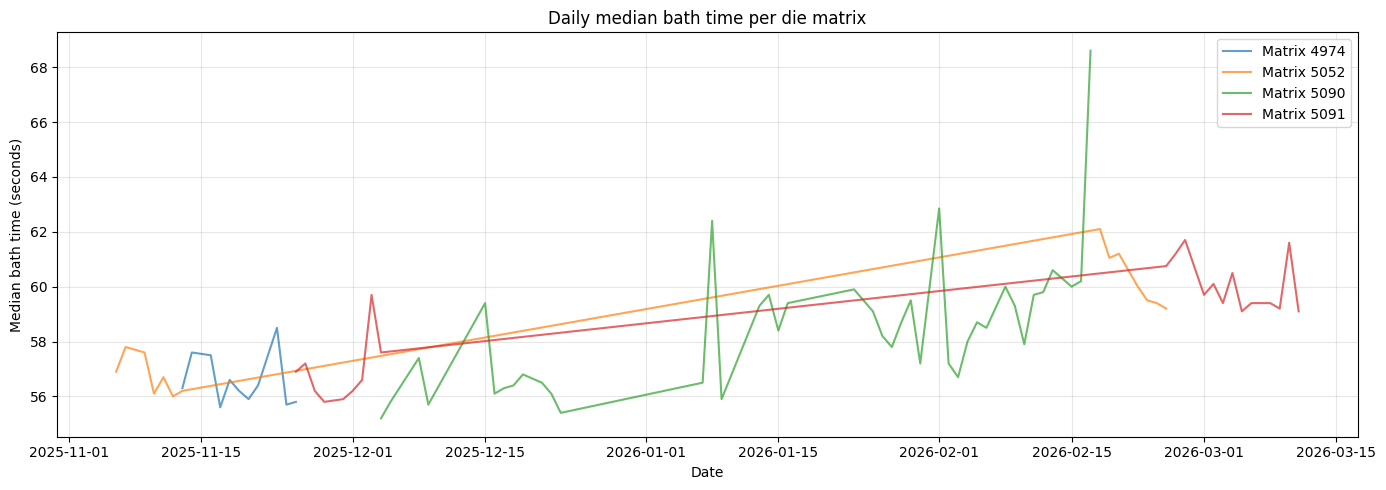

In [13]:
# TODO: implement this cell

df["date"] = pd.to_datetime(df["timestamp"]).dt.date

daily = df.groupby(["date", "die_matrix"])["lifetime_bath_s"].median().reset_index()
daily.columns = ["date", "die_matrix", "median_bath_s"]

fig, ax = plt.subplots(figsize=(14, 5))

for matrix in sorted(df["die_matrix"].unique()):
  d = daily[daily["die_matrix"] == matrix]
  ax.plot(d["date"], d["median_bath_s"], label=f"Matrix {matrix}", alpha=0.7)

ax.set_title("Daily median bath time per die matrix")
ax.set_xlabel("Date")
ax.set_ylabel("Median bath time (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Segment variability ranking

Across all matrices, which process segment is the most unstable? This is where maintenance and process engineering should focus attention.

In [14]:
# TODO: implement this cell

cv_all = df[partial_cols].agg(["std", "median"])
cv_ranking = (cv_all.loc["std"] / cv_all.loc["median"] * 100).sort_values(ascending=False).round(1)

print("=== SEGMENT VARIABILITY RANKING (CV across all matrices) ===")
print("Higher = more unstable = priority for process improvement")
print()
for segment, cv in cv_ranking.items():
  clean_name = segment.replace("partial_", "").removesuffix("_s")
  print(f"  {clean_name:<45} CV: {cv:.1f}%")



=== SEGMENT VARIABILITY RANKING (CV across all matrices) ===
Higher = more unstable = priority for process improvement

  furnace_to_2nd_strike                         CV: 12.9%
  2nd_to_3rd_strike                             CV: 10.2%
  4th_strike_to_auxiliary_press                 CV: 8.1%
  3rd_to_4th_strike                             CV: 7.8%
  auxiliary_press_to_bath                       CV: 5.6%


## 9. Summary

Key findings from the per-matrix analysis.

In [15]:
# TODO: implement this cell

print("=" * 55)
print("PER-MATRIX ANALYSIS SUMMARY")
print("=" * 55)
print()
print("REFERENCE BATH TIMES (median):")
for matrix, val in df.groupby("die_matrix")["lifetime_bath_s"].median().items():
  print(f"  Matrix {matrix}: {val:.1f}s")
print()
print("SLOW PIECES (> 90th percentile per matrix):")
print(f"  Total: {len(df_slow):,} ({len(df_slow)/len(df)*100:.1f}% of all pieces)")
print(f"  Most penalized segment: furnace_to_2nd_strike (78% of slow pieces)")
print()
print("MOST VARIABLE SEGMENTS (CV):")
for segment, cv in cv_ranking.items():
  clean_name = segment.replace("partial_", "").removesuffix("_s")
  print(f"  {clean_name:<45} {cv:.1f}%")
print()
print("DRIFT DETECTED:")
print("  Matrix 5052 shows progressive bath time increase")
print("  over its active period (Nov 2025 – Feb 2026),")
print("  consistent with tooling wear.")
print("=" * 55)

PER-MATRIX ANALYSIS SUMMARY

REFERENCE BATH TIMES (median):
  Matrix 4974: 56.0s
  Matrix 5052: 58.3s
  Matrix 5090: 58.1s
  Matrix 5091: 59.1s

SLOW PIECES (> 90th percentile per matrix):
  Total: 16,549 (9.8% of all pieces)
  Most penalized segment: furnace_to_2nd_strike (78% of slow pieces)

MOST VARIABLE SEGMENTS (CV):
  furnace_to_2nd_strike                         12.9%
  2nd_to_3rd_strike                             10.2%
  4th_strike_to_auxiliary_press                 8.1%
  3rd_to_4th_strike                             7.8%
  auxiliary_press_to_bath                       5.6%

DRIFT DETECTED:
  Matrix 5052 shows progressive bath time increase
  over its active period (Nov 2025 – Feb 2026),
  consistent with tooling wear.
